# 1. Descriptive Statistics

In [4]:
import pandas as pd

## 1.1 Basic Example

### 1.1.1 Download

In [5]:
def download_macro_data(url):
    """Downloads macroeconomic data from a URL and returns a pandas DataFrame."""
    print(f"Fetching macroeconomic data from: {url}")
    df = pd.read_stata(url)
    return df

In [6]:
url_macro = 'https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_unemp.dta'
df_unemp_raw = download_macro_data(url_macro)
df_unemp_raw.head(2)

Fetching macroeconomic data from: https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_unemp.dta


,ISO3,year,ADB_unemp,AFDB_unemp,AHSTAT_unemp,AMECO_unemp,EUS_unemp,HFS_unemp,ILO_unemp,IMF_IFS_unemp,IMF_WEO_unemp,JST_unemp,OECD_EO_unemp,OECD_KEI_unemp,CS1_unemp,unemp,chainlinking_ratio,source,source_change
0,ZWE,2023.0,NaN,NaN,NaN,NaN,NaN,NaN,9.348,NaN,NaN,NaN,NaN,NaN,NaN,9.348,1.0,ILO,1.0
1,ZWE,2022.0,NaN,NaN,NaN,NaN,NaN,NaN,10.087,10.139,NaN,NaN,NaN,NaN,NaN,10.139,1.0,IMF_IFS,NaN


### 1.1.2 Filter Columns

In [9]:
df_unemp = df_unemp_raw[['ISO3', 'year', 'unemp', 'AFDB_unemp', 'source']]
df_unemp.head(4)

,ISO3,year,unemp,AFDB_unemp,source
0,ZWE,2023.0,9.348,NaN,ILO
1,ZWE,2022.0,10.139,NaN,IMF_IFS
2,ZWE,2021.0,9.540,NaN,IMF_IFS
3,ZWE,2020.0,7.373,NaN,IMF_IFS


### 1.1.3 Filter country

In [10]:
df_unemp_zimbabwe = df_unemp.query("ISO3 == 'ZWE'")
df_unemp_zimbabwe.head(5)

,ISO3,year,unemp,AFDB_unemp,source
0,ZWE,2023.0,9.348,NaN,ILO
1,ZWE,2022.0,10.139,NaN,IMF_IFS
2,ZWE,2021.0,9.540,NaN,IMF_IFS
3,ZWE,2020.0,7.373,NaN,IMF_IFS
4,ZWE,2019.0,7.373,NaN,IMF_IFS


### 1.1.4 Drop column

In [11]:
df_unemp_zimbabwe = df_unemp_zimbabwe.drop(['ISO3'], axis='columns')
df_unemp_zimbabwe.head(5)

,year,unemp,AFDB_unemp,source
0,2023.0,9.348,NaN,ILO
1,2022.0,10.139,NaN,IMF_IFS
2,2021.0,9.540,NaN,IMF_IFS
3,2020.0,7.373,NaN,IMF_IFS
4,2019.0,7.373,NaN,IMF_IFS


### 1.1.5 Set index

In [12]:
df_unemp_zimbabwe = df_unemp_zimbabwe.set_index("year").dropna().sort_index()
df_unemp_zimbabwe

,unemp,AFDB_unemp,source
year,,,
2004.0,4.390,4.17,IMF_IFS
2011.0,5.368,5.37,IMF_IFS
2014.0,4.774,11.32,IMF_IFS


### 1.1.6 Plot

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='year'>

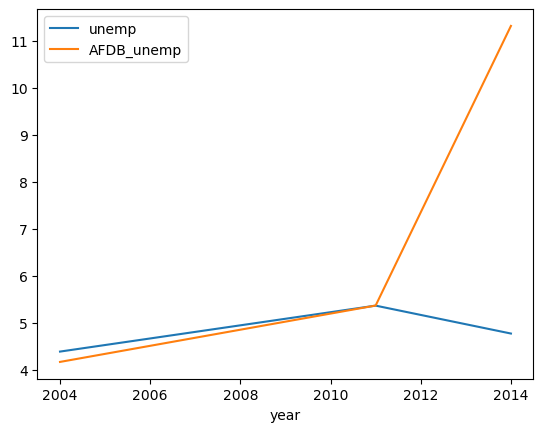

In [13]:
df_unemp_zimbabwe.plot()

### 1.1.6 Show descriptive stats

In [14]:
df_unemp['unemp'].describe()

count    7645.000000
mean        7.686186
std         6.259884
min         0.000000
25%         3.475000
50%         6.058000
75%         9.800000
max        70.000000
Name: unemp, dtype: float64

<Axes: >

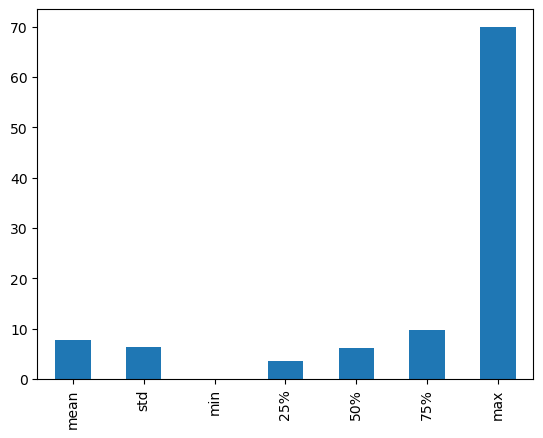

In [ ]:
df_unemp['unemp'].describe().drop(['count'], axis = 0).plot(kind = 'bar')

## 1.2 Groupby (mean, max, min by certain group)

- Below we are grouping by ISO3 (country) across all time

### 1.2.1 By Country (Get stats by country)

- In this case unemployment average, max etc BY COUNTRY

#### Create descriptive stats

In [16]:
df_unemp_descriptive_bycountry = df_unemp.groupby('ISO3')['unemp'].describe()
df_unemp_descriptive_bycountry.head(2)

,count,mean,std,min,25%,50%,75%,max
ISO3,,,,,,,,
ABW,39.0,7.088641,1.902090,3.250,6.05350,6.90000,8.70000,11.4
AFG,13.0,8.300230,7.950101,1.692,3.37019,3.37046,8.22908,23.9


#### Filter Mean column only

In [24]:
df_plot = df_unemp_descriptive_bycountry['count'].head(5).sort_values()
df_plot

ISO3
AIA     6.0
AGO    11.0
AFG    13.0
ABW    39.0
ALB    50.0
Name: count, dtype: float64

#### Graph

Text(0.5, 1.0, 'Mean unemployment by country over sample')

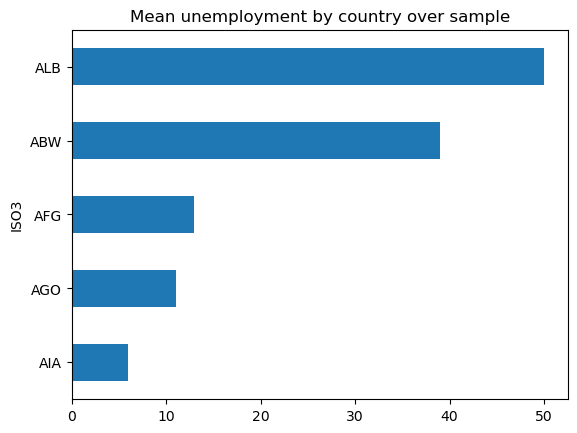

In [25]:
import matplotlib.pyplot as plt
df_plot.plot(kind = 'barh')
plt.title("Mean unemployment by country over sample")

<Axes: xlabel='ISO3'>

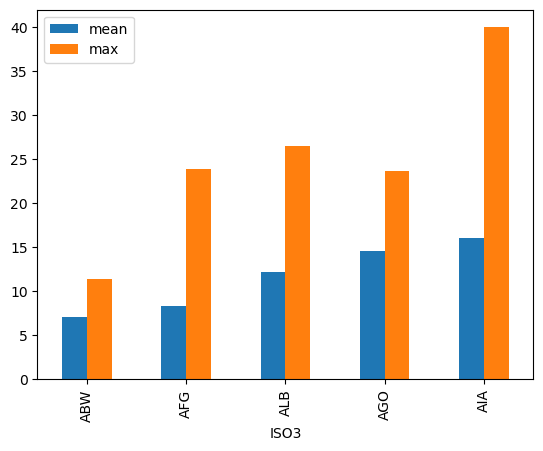

In [26]:
df_unemp_descriptive_bycountry[['mean', 'max']].head(5).sort_values(by = 'mean').plot(kind = 'bar')

#### Refresher: (1) on using dictionary to rename (2) filter specific country rows

In [27]:
# Website with country codes https://www.iban.com/country-codes
country_code = pd.read_html('https://www.iban.com/country-codes')[0]
country_code.head(2)

,Country,Alpha-2 code,Alpha-3 code,Numeric
0,Afghanistan,AF,AFG,4
1,Åland Islands,AX,ALA,248


In [28]:
country_map = dict(country_code[['Alpha-3 code', 'Country']].head(5).values)
country_map

{'AFG': 'Afghanistan',
 'ALA': 'Åland Islands',
 'ALB': 'Albania',
 'DZA': 'Algeria',
 'ASM': 'American Samoa'}

In [29]:
country_map = dict(country_code[['Alpha-3 code', 'Country']].values)
#country_map

In [30]:
country_list = ["JPY", "GIB", "FRA"]
df_plot = df_unemp_descriptive_bycountry['max'].rename(country_map, axis='index').sort_values()
df_plot.head(5)

ISO3
Qatar            1.480
Benin            2.647
Liechtenstein    2.660
Kuwait           2.900
Guinea-Bissau    3.127
Name: max, dtype: float64

In [33]:
df_plot = df_plot.query("ISO3 in ['France', 'Japan', 'China', 'Greece']")
df_plot.head(4)

,max
ISO3,
China,5.617
Japan,6.800
France,15.400
Greece,27.475


Text(0.5, 1.0, 'Max Unemployment by Country in Sample')

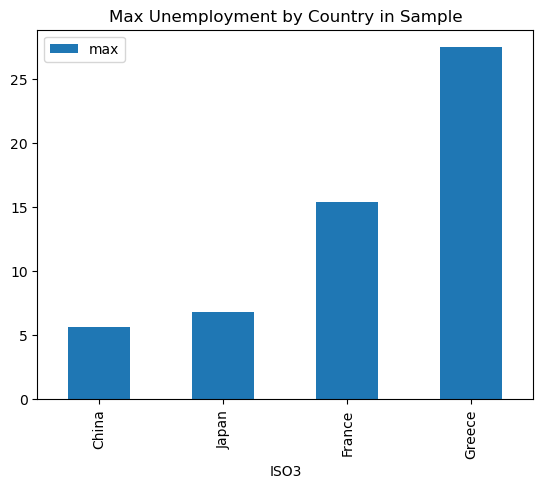

In [28]:
df_plot.plot(kind = 'bar')
plt.title("Max Unemployment by Country in Sample")

### 1.2.2 Groupby date (Get stats by date)

- In this case unemployment average, max etc BY DATE!!

In [29]:
df_unemp_datetime = df_unemp.copy()
df_unemp_datetime.year = pd.to_datetime(df_unemp_datetime.year, format = "%Y")
df_unemp_datetime.head(2)

,ISO3,year,unemp
0,ZWE,2023-01-01,9.348
1,ZWE,2022-01-01,10.139


In [30]:
df_unemp_descriptive_bydate = df_unemp.groupby('year')['unemp'].describe()
df_unemp_descriptive_bydate.head(2)

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
1760.0,1.0,3.626304,NaN,3.626304,3.626304,3.626304,3.626304,3.626304
1761.0,1.0,3.114833,NaN,3.114833,3.114833,3.114833,3.114833,3.114833


<Axes: xlabel='year'>

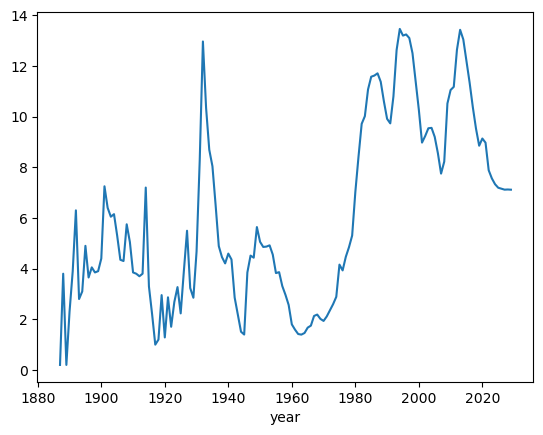

In [34]:
df_unemp.query("ISO3 in ['FRA', 'DEU', 'ESP', 'ITA']").groupby('year')['unemp'].mean().plot()